# Notebook Objectives

This notebook computes neural values for one session. For all sessions, we do the same in ```neural_value_RUN_all_sessions.py```, results shown in ```neural_value_all_sessions.ipynb```.

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)
* Change in neural value, etc

---
# Setup


In [1]:
from neural_value_helpers import *
from popy.config import COLORS

In [2]:
##% data loading
def load_mega_custom(monkey=None, area=None, subregion=None, downsample=True):
    # load data (meta session)
    floc = os.path.join(PATH, 'data', 'processed', 'neural_data', 'meta_rates_history')
    neural_dataset =  xr.open_dataset(floc + '/meta_rates.nc')

    if area is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.area == area)
    if subregion is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.subregion == subregion)

    if monkey is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.monkey == monkey)

    # use only time points of every .1 s
    if downsample:
        time_vector = neural_dataset.time.values
        time_vector = np.unique(np.round(time_vector, 1))  # round to 1 decimal place to avoid floating point issues
        neural_dataset = neural_dataset.sel(time=time_vector, method='nearest')

    # add coordinates (should be added during the dataset creation)
    neural_dataset = neural_dataset.assign_coords(R_1=('trial_id', [0 if hist in [0, 1, 2, 3] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_2=('trial_id', [0 if hist in [0, 1, 4, 5] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_3=('trial_id', [0 if hist in [0, 2, 4, 6] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(fb_sequence=('trial_id', neural_dataset.history_of_feedback.values))
    neural_dataset = neural_dataset.assign_coords(fb_sequence_m1=('trial_id', neural_dataset.history_of_feedback.values%4))
    neural_dataset = neural_dataset.assign_coords(time_m1=('time', neural_dataset.time.values + 7.5))

    # normalize firing rates (z-score) and remove units with low firing rates
    threshold = 1  # Hz
    units_to_remove = []
    normalized_data = np.zeros_like(neural_dataset.firing_rates.data)  # Create a copy to avoid modifying the original data
    for i, unit in enumerate(neural_dataset.unit.values):  # Loop through each neuron
        # Get all data for this neuron across trials and timepoints
        unit_data = neural_dataset.firing_rates.sel(unit=unit).values
        
        # Calculate mean and std across all values for this neuron
        mean_val = np.mean(unit_data)
        std_val = np.std(unit_data)
        
        # Z-score normalize and store in the output array
        if mean_val < threshold:
            units_to_remove.append(unit)
        elif std_val == 0:
            raise ValueError(f"Standard deviation is zero for unit {unit}. Not possible.")
        else:
            z_scored_data = (unit_data - mean_val) / std_val        
            normalized_data[:, i, :] = z_scored_data
    #neural_dataset.firing_rates.values = normalized_data
    neural_dataset['firing_rates'] = (neural_dataset.firing_rates.dims, normalized_data)

    neural_dataset = neural_dataset.sel(unit=~neural_dataset.unit.isin(units_to_remove))
    print(f"Removed {len(units_to_remove)} units with mean firing rate < {threshold} Hz")

    return neural_dataset

---
# Section 1: Get data, extract neural value

In [3]:
monkey, session, subregion = 'ka', '210322', 'MCC'

t_interest_value = [2, 3.5]  # seconds
build_data = True

all_figs = []

In [4]:
neural_dataset = load_mega_custom(monkey='ka', subregion='MCC')

Removed 85 units with mean firing rate < 1 Hz


In [5]:
'''floc = 'data/{}_{}_neural.nc'.format(monkey, session)

if not build_data: 
    neural_dataset_all = xr.open_dataset(floc)
else:
    neural_dataset_all = load_data_custom(monkey, session, n_extra_trials=(-1, 1), sr=10)
    # save the dataset
    neural_dataset_all.to_netcdf(floc)

neural_dataset = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
neural_dataset'''

"floc = 'data/{}_{}_neural.nc'.format(monkey, session)\n\nif not build_data: \n    neural_dataset_all = xr.open_dataset(floc)\nelse:\n    neural_dataset_all = load_data_custom(monkey, session, n_extra_trials=(-1, 1), sr=10)\n    # save the dataset\n    neural_dataset_all.to_netcdf(floc)\n\nneural_dataset = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)\nneural_dataset"

## Projection to value subspace

In [6]:
#results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset, target='R_1', across_time=False)

# get neural value for the current trial and the previous one
data_projected = add_neural_value_coord(data_projected, t_interest=t_interest_value)

AttributeError: 'DataArray' object has no attribute 'stay_value'

In [ ]:
# save data_projected
#data_projected.to_netcdf('data/{}_{}_data_proj.nc'.format(monkey, session))

# load data_projected
#data_projected = xr.open_dataset('data/{}_{}_data_proj.nc'.format(monkey, session))

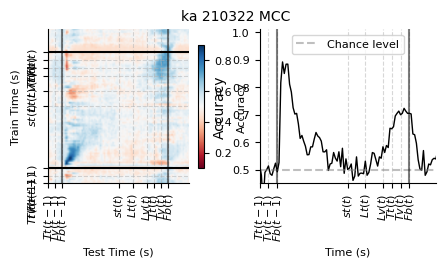

In [ ]:
# Plot the results
fig, axes = plot_across_time_decodability(projected_data=data_projected, decodability_matrix=decodability_matrix, vmin=0.1, vmax=.9)

plt.suptitle('{} {} {}'.format(monkey, session, subregion), fontsize=10)

# Save the figure
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_across_time_decodability.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

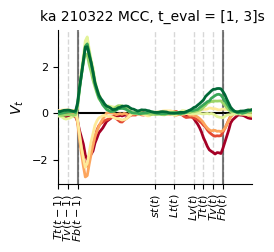

In [ ]:
fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
# hide legend
plt.suptitle(f'{monkey} {session} {subregion}, t_eval = {t_interest_value}s', fontsize=10)

# save figure
fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_projection.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

In [ ]:
from matplotlib.lines import Line2D

def plot_projected_data_switch(data_projected, t_interest_value=None, normalize=False, n_extra_trials=(0, 1), xlim=None, paper_format=False, ax=None):
    # project to axis
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        h = 2  # in cm
        w = 2.5
        linewidth = 2
    else:
        plt.rcParams.update({'font.size': 12})
        h = 6  # in cm
        w = 8  # in cm
        linewidth = 1.5

    r1s = [0, 1]
    r2s = [0, 1]
    target1s = [0, 1]  # 0: no switch, 1: switch

    colors = value_gradient(4)
    linestyles = {1: '-', 0: '--'}
    target_labels = {1: 'target 1', 0: 'target 2 or 3'}
    hist_labels = {(0, 0): '$R_{t-1}=0, R_t=0$', (0, 1): '$R_{t-1}=1, R_t=0$', (1, 0): '$R_{t-1}=0, R_t=1$', (1, 1): '$R_{t-1}=1, R_t=1$'}

    if ax is None:
        fig, ax = plt.subplots(figsize=(w, h))

    # 500 ms for convolution
    dt = data_projected.time.values[1] - data_projected.time.values[0]
    n_convolution_bins = int(1 / dt)
    window = np.ones(n_convolution_bins) / n_convolution_bins

    time_vector = data_projected.time.values

    # bwr colormap, n=8 sampples RdYlGn
        
    for i_s, target1 in enumerate(target1s):
        for i_past, (r1, r2) in enumerate(itertools.product(r1s, r2s)):
            data_temp = data_projected.sel(
                trial_id=(data_projected.target_1 == target1) & (data_projected.feedback == r1) & (data_projected.R_1 == r2)
                )

            class_mean = data_temp.mean(dim='trial_id').values
            class_mean_smoothed = ndimage.convolve(class_mean, window, mode='nearest')

            ax.plot(time_vector, class_mean_smoothed, color=colors[i_past], label=f'{target_labels[target1]}, \t\t{hist_labels[(r1, r2)]}', linewidth=linewidth, zorder=10, linestyle=linestyles[target1])

    if t_interest_value is not None:
        ax.axvspan(t_interest_value[0], t_interest_value[1], color='grey', alpha=0.2, label='eval window')

    # add behav keyboints
    plot_keypoints(ax, n_extra_trials, mark_event='Fb', xlabels='events')
    # y grid only
    ax.grid(axis='x', alpha=.5, linewidth=1, linestyle='--')
    ax.axhline(0, color='k', linestyle='-', linewidth=linewidth*.75, zorder=0)

    # remove left and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Apply the custom legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    # move legend outside
    if not paper_format:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # save as svg
    ax.set_ylabel('$V_t$', fontsize=10)
    '''if title is not None:
        ax.set_title(title)
    else:
        ax.set_title('Neural value')'''
    
    if xlim is not None:    
        ax.set_xlim(xlim)

    return fig, ax

# plot_projected_data_switch(data_projected, t_interest_value=None, n_extra_trials=(-1, 1), paper_format=False)

## Extract neural value

In [ ]:
behav_new = data_projected.mean('time').coords.to_dataset().to_dataframe().reset_index()

behav_new['monkey'] = monkey
behav_new['session'] = session
#behav_new['area'] = neural_dataset.area
behav_new['subregion'] = subregion

# put monkey, session, subregion in the front
behav_new = behav_new[['monkey', 'session', 'subregion'] +
                       [c for c in behav_new.columns if c not in ['monkey', 'session', 'subregion']]]
behav_new = behav_new.dropna()
behav_new


,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,R_7,R_8,fb_sequence,target_1,V_t,V_t_p1,dV,V_t_behav,V_t_p1_behav,dV_behav
0,ka,210322,MCC,8,0,1,3.0,0.0,1.0,0.167107,...,0.0,0.0,1.0,False,0.167695,0.059361,-0.108333,0.167107,0.069825,-0.097282
1,ka,210322,MCC,9,0,1,1.0,1.0,1.0,0.069825,...,1.0,0.0,0.0,True,0.059361,0.115802,0.056441,0.069825,0.479459,0.409634
2,ka,210322,MCC,10,0,1,1.0,1.0,0.0,0.479459,...,0.0,1.0,4.0,True,0.115802,0.335741,0.219939,0.479459,0.692690,0.213231
3,ka,210322,MCC,11,0,1,1.0,1.0,0.0,0.692690,...,0.0,0.0,6.0,True,0.335741,0.666695,0.330955,0.692690,0.818575,0.125884
4,ka,210322,MCC,12,0,1,1.0,1.0,0.0,0.818575,...,1.0,0.0,7.0,True,0.666695,1.386850,0.720155,0.818575,0.892892,0.074318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,ka,210322,MCC,410,9,3,3.0,0.0,0.0,0.849841,...,1.0,1.0,6.0,False,-0.130840,-0.358399,-0.227559,0.849841,0.501718,-0.348123
380,ka,210322,MCC,415,9,3,3.0,1.0,0.0,0.387067,...,1.0,0.0,2.0,False,-0.007480,-0.278310,-0.270830,0.387067,0.638145,0.251078
381,ka,210322,MCC,416,9,3,3.0,1.0,0.0,0.638145,...,1.0,1.0,5.0,False,-0.278310,-0.178203,0.100107,0.638145,0.786373,0.148228
382,ka,210322,MCC,417,9,3,3.0,0.0,0.0,0.786373,...,0.0,1.0,6.0,False,-0.178203,-0.395047,-0.216844,0.786373,0.464248,-0.322125


In [ ]:
# save behav_new to csv
behav_new.to_csv(f'data/{monkey}_{session}_{subregion}_neural_value.csv', index=False)

---
# Section 2: Analysis of the neural value representation

## Green red plot: Value evolves according to feedback

Spearman correlation (rho): 0.589, p-value: 1.81e-36


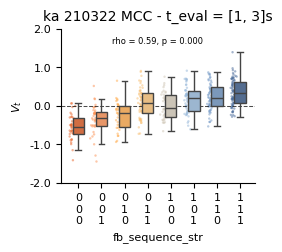

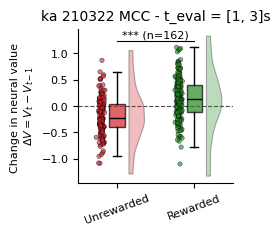

In [ ]:
'''fig, ax = plot_projection_timepoint(behav_new, paper_format=True, ylim=None, show_datapoints=True)

plt.suptitle(f'{monkey} {session} {subregion}, t_fit = {t_interest_value} s', fontsize=10)

all_figs.append(fig)
'''

fig, ax = plot_Vt_per_sequence(behav_new, paper_format=True, ylim=None, show_datapoints=True, showfliers=False)
ax.set_title(f'{monkey} {session} {subregion} - t_eval = {t_interest_value}s', fontsize=10)
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_Vt_per_sequence.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

fig, ax = create_r_style_plot(None, behav_new, 'feedback', 'dV', paper_format=True)
ax.set_title(f'{monkey} {session} {subregion} - t_eval = {t_interest_value}s', fontsize=10)
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_feedback_dV.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

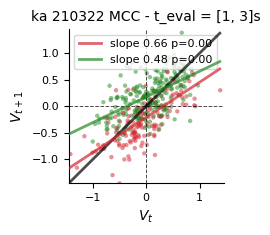

In [ ]:
fig, ax = green_red_plot(behav_new, paper_format=True)
#plt.suptitle(f'{monkey} {session} {subregion}, t_fit = {t_interest_value} s', fontsize=10)

ax.set_title(f'{monkey} {session} {subregion} - t_eval = {t_interest_value}s', fontsize=10)

#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_green_red.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

In [ ]:
n_perms = 100

cpds_all = process_single_session(behav_new)
#cpds_all = add_corrected_pvals(pd.DataFrame([cpds_all]))
cpds_all = pd.DataFrame([cpds_all])
cpds_all

,cpd_R_1,pval_R_1,cpd_R_2,pval_R_2,cpd_R_3,pval_R_3,cpd_R_4,pval_R_4,cpd_R_5,pval_R_5,cpd_R_6,pval_R_6,cpd_R_7,pval_R_7,cpd_R_8,pval_R_8,monkey,session,subregion
0,52.540711,0.009901,22.132031,0.009901,10.280607,0.009901,4.583756,0.009901,2.069287,0.029703,1.505031,0.049505,0.003957,0.950495,0.222178,0.445545,ka,210322,MCC


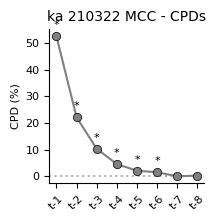

In [ ]:
#null = create_permutation_null(behav_new, n_perms=100)

fig, axs = plot_cpds_history_neural_value(cpds_all)

# remove title from axes
axs.set_title(f'{monkey} {session} {subregion} - CPDs', fontsize=10)

#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_cpds.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

---
# Save figs